#**Implementation of Support Vector Machine (SVM) using a real dataset (Breast Cancer Dataset)**

**Step 1: Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Step 2: Load Real Dataset**

In [ ]:
data = load_breast_cancer()

# data.data: Numerical Value
# data.feature_names: Feature name
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target (output) column to the DataFrame
# Target = 0 (Malignant - Cancerous)
# Target = 1 (Benign - Non-cancerous)
df['Target'] = data.target

df.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
382,12.050,22.72,78.75,447.8,0.06935,0.10730,0.079430,0.02978,0.1203,0.06659,...,28.71,87.36,488.4,0.08799,0.32140,0.29120,0.10920,0.2191,0.09349,1
131,15.460,19.48,101.70,748.9,0.10920,0.12230,0.146600,0.08087,0.1931,0.05796,...,26.00,124.90,1156.0,0.15460,0.23940,0.37910,0.15140,0.2837,0.08019,0
493,12.460,12.83,78.83,477.3,0.07372,0.04043,0.007173,0.01149,0.1613,0.06013,...,16.36,83.24,534.0,0.09439,0.06477,0.01674,0.02680,0.2280,0.07028,1
101,6.981,13.43,43.79,143.5,0.11700,0.07568,0.000000,0.00000,0.1930,0.07818,...,19.54,50.41,185.2,0.15840,0.12020,0.00000,0.00000,0.2932,0.09382,1
266,10.600,18.95,69.28,346.4,0.09688,0.11470,0.063870,0.02642,0.1922,0.06491,...,22.94,78.28,424.8,0.12130,0.25150,0.19160,0.07926,0.2940,0.07587,1


In [ ]:
df.shape

(569, 31)

**Step 3: Select Only  Features (For Visualization)**

Decision boundaries can only be drawn in 2D, so we'll use only two features.

In [ ]:
X = df[['mean radius', 'mean texture',]]

y = df['Target']

**Step 4: Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Step 5: Feature Scaling**

SVM works best when features are scaled.

In [ ]:
# Create an object of the StandardScaler class
scaler = StandardScaler()

# Learn the mean and standard deviation from the training data
# Then transform the training data so that:
# Mean = 0
# Standard Deviation = 1
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**Step 6: Train SVM Model**

In [ ]:
#svm = SVC(kernel='linear')
#svm = SVC(kernel='rbf')
#svm = SVC(kernel='sigmoid')
svm = SVC(kernel='poly', degree=3)
svm.fit(X_train, y_train)

SVC(kernel='poly')

**Step 7: Prediction**

In [ ]:
y_pred = svm.predict(X_test)

In [ ]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

**Step 8: Accuracy**

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))

NameError: name 'y_test' is not defined

**Step 9: Confusion Matrix**

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[38  5]
 [ 4 67]]


**Step 10: Classification Report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        43
           1       0.93      0.94      0.94        71

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.92       114
weighted avg       0.92      0.92      0.92       114



Step 11: Visualize Support Vectors & Decision Boundary

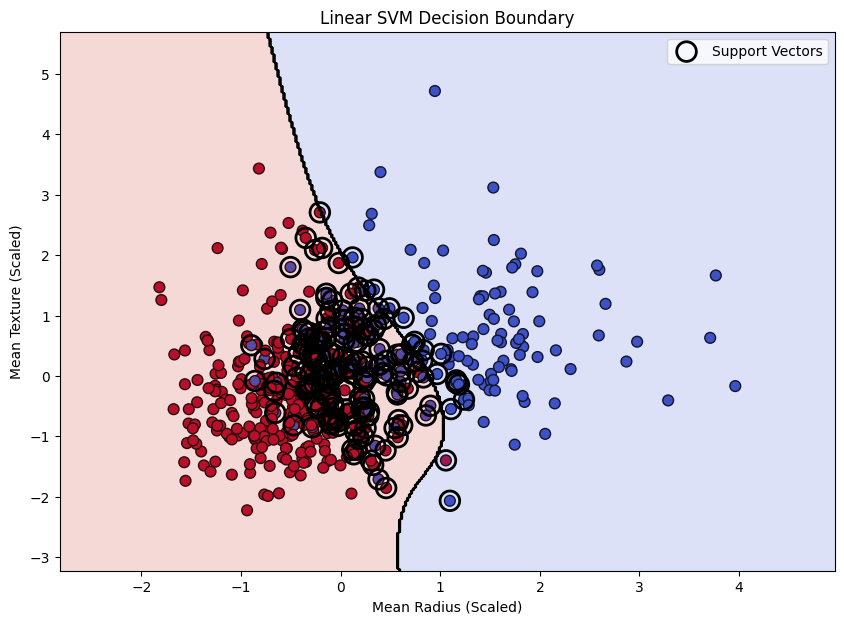

In [ ]:
plt.figure(figsize=(10,7))

# Plot data points
plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap='coolwarm',
    edgecolors='k',
    s=60
)

# Create mesh grid
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Decision Boundary
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2,
    cmap='coolwarm'
)

# Decision Line
plt.contour(
    xx,
    yy,
    Z,
    colors='black',
    linewidths=1
)

# Support Vectors
plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

plt.xlabel("Mean Radius (Scaled)")
plt.ylabel("Mean Texture (Scaled)")
plt.title("Linear SVM Decision Boundary")

plt.legend()

plt.show()

**Expected Accuracy**

Using the two selected features, a linear SVM typically achieves around 85–92% accuracy. If you use all 30 features from the dataset (without limiting to two for visualization), accuracy is usually 95–99%.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare data using all features
X = df.drop('Target', axis=1)
y = df['Target']

# 2. Split the data (This defines y_test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Set up and run Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

# 5. Make predictions (This defines y_pred)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 6. Print accuracy
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.9824561403508771
